In [ ]:
#  https://www.youtube.com/watch?v=QIUxPv5PJOY
#Description: This program uses an artificial recurrent neural network called Long Short Term Memory (LSTM)
#             to predict the closing stock price of a corporation (Apple Inc.) using the past 60 day stock price.
#uruchomienie w terminalu: python3 stock_price_prediction.py lub w COLAB

In [95]:
import numpy as np
import math
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [96]:
import warnings
import cudf
import pandas as pd
from io import StringIO
warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)
df = pd.read_csv('DaneModelTMP_4klasy.csv', delimiter=';')
df

,czas,data,Pora,miesiac,Widz3,Widz6,Zachm3,Zachm6,ZachmN3,ZachmN6,...,OpadM_E,OpadM_N,OpadM_S,Przelotny_W,Przelotny_E,Przelotny_N,Przelotny_S,Pred3,Pred6,id
0,06.08.2013 04:00,06.08.2013,1,8,30000,30000,0.000000,0.000000,0.000000,0.000000,...,0,0,0,0,0,0,0,-1,0,169
1,06.08.2013 08:00,06.08.2013,2,8,20000,23333,1.000000,0.500000,0.000000,0.000000,...,0,0,0,0,0,0,0,-1,0,170
2,06.08.2013 12:00,06.08.2013,3,8,30000,26666,2.333333,1.833333,1.333333,0.833333,...,0,0,0,0,0,0,0,-1,0,171
3,06.08.2013 16:00,06.08.2013,4,8,30000,30000,2.666666,2.666666,1.666666,1.666666,...,0,0,0,0,0,0,0,-1,0,172
4,06.08.2013 20:00,06.08.2013,5,8,30000,30000,2.000000,2.166666,1.000000,1.166666,...,0,0,0,0,0,0,0,-1,0,173
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152765,21.12.2022 23:00,21.12.2022,5,12,2266,3216,8.000000,8.000000,8.000000,7.666666,...,0,0,0,1,0,0,0,-1,2,180009
152766,22.12.2022 00:00,22.12.2022,0,12,2533,2883,8.000000,8.000000,7.666666,7.666666,...,0,0,0,0,0,0,0,-1,2,180010
152767,22.12.2022 01:00,22.12.2022,0,12,2800,2750,8.000000,8.000000,7.333333,7.666666,...,0,0,0,0,0,1,0,-1,2,180011
152768,22.12.2022 02:00,22.12.2022,0,12,2500,2383,8.000000,8.000000,7.000000,7.500000,...,0,0,0,0,0,1,0,-1,2,180012


In [97]:
df = df.set_index('czas')

In [98]:
#Get the number of rows and columns in the data set
# df.drop(['data'], axis= 1)

In [99]:
# df['czas'].iloc[0]

In [100]:
df.index[0]

'06.08.2013 04:00'

In [102]:
from datetime import datetime
# Przykładowa wartość daty i czasu
for i in range(len(df)):
    value = df.index[i]

    # Konwersja na obiekt datetime
    datetime_object = datetime.strptime(value, "%d.%m.%Y %H:%M")

    # Konwersja na sekundy od początku epoki (1 stycznia 1970)
    seconds_since_epoch = datetime_object.timestamp()

    df['sekundy'] = seconds_since_epoch

In [103]:
df['sekundy']

czas
06.08.2013 04:00    1.671678e+09
06.08.2013 08:00    1.671678e+09
06.08.2013 12:00    1.671678e+09
06.08.2013 16:00    1.671678e+09
06.08.2013 20:00    1.671678e+09
                        ...     
21.12.2022 23:00    1.671678e+09
22.12.2022 00:00    1.671678e+09
22.12.2022 01:00    1.671678e+09
22.12.2022 02:00    1.671678e+09
22.12.2022 03:00    1.671678e+09
Name: sekundy, Length: 152770, dtype: float64

In [104]:
df_plot = df.head(1000)

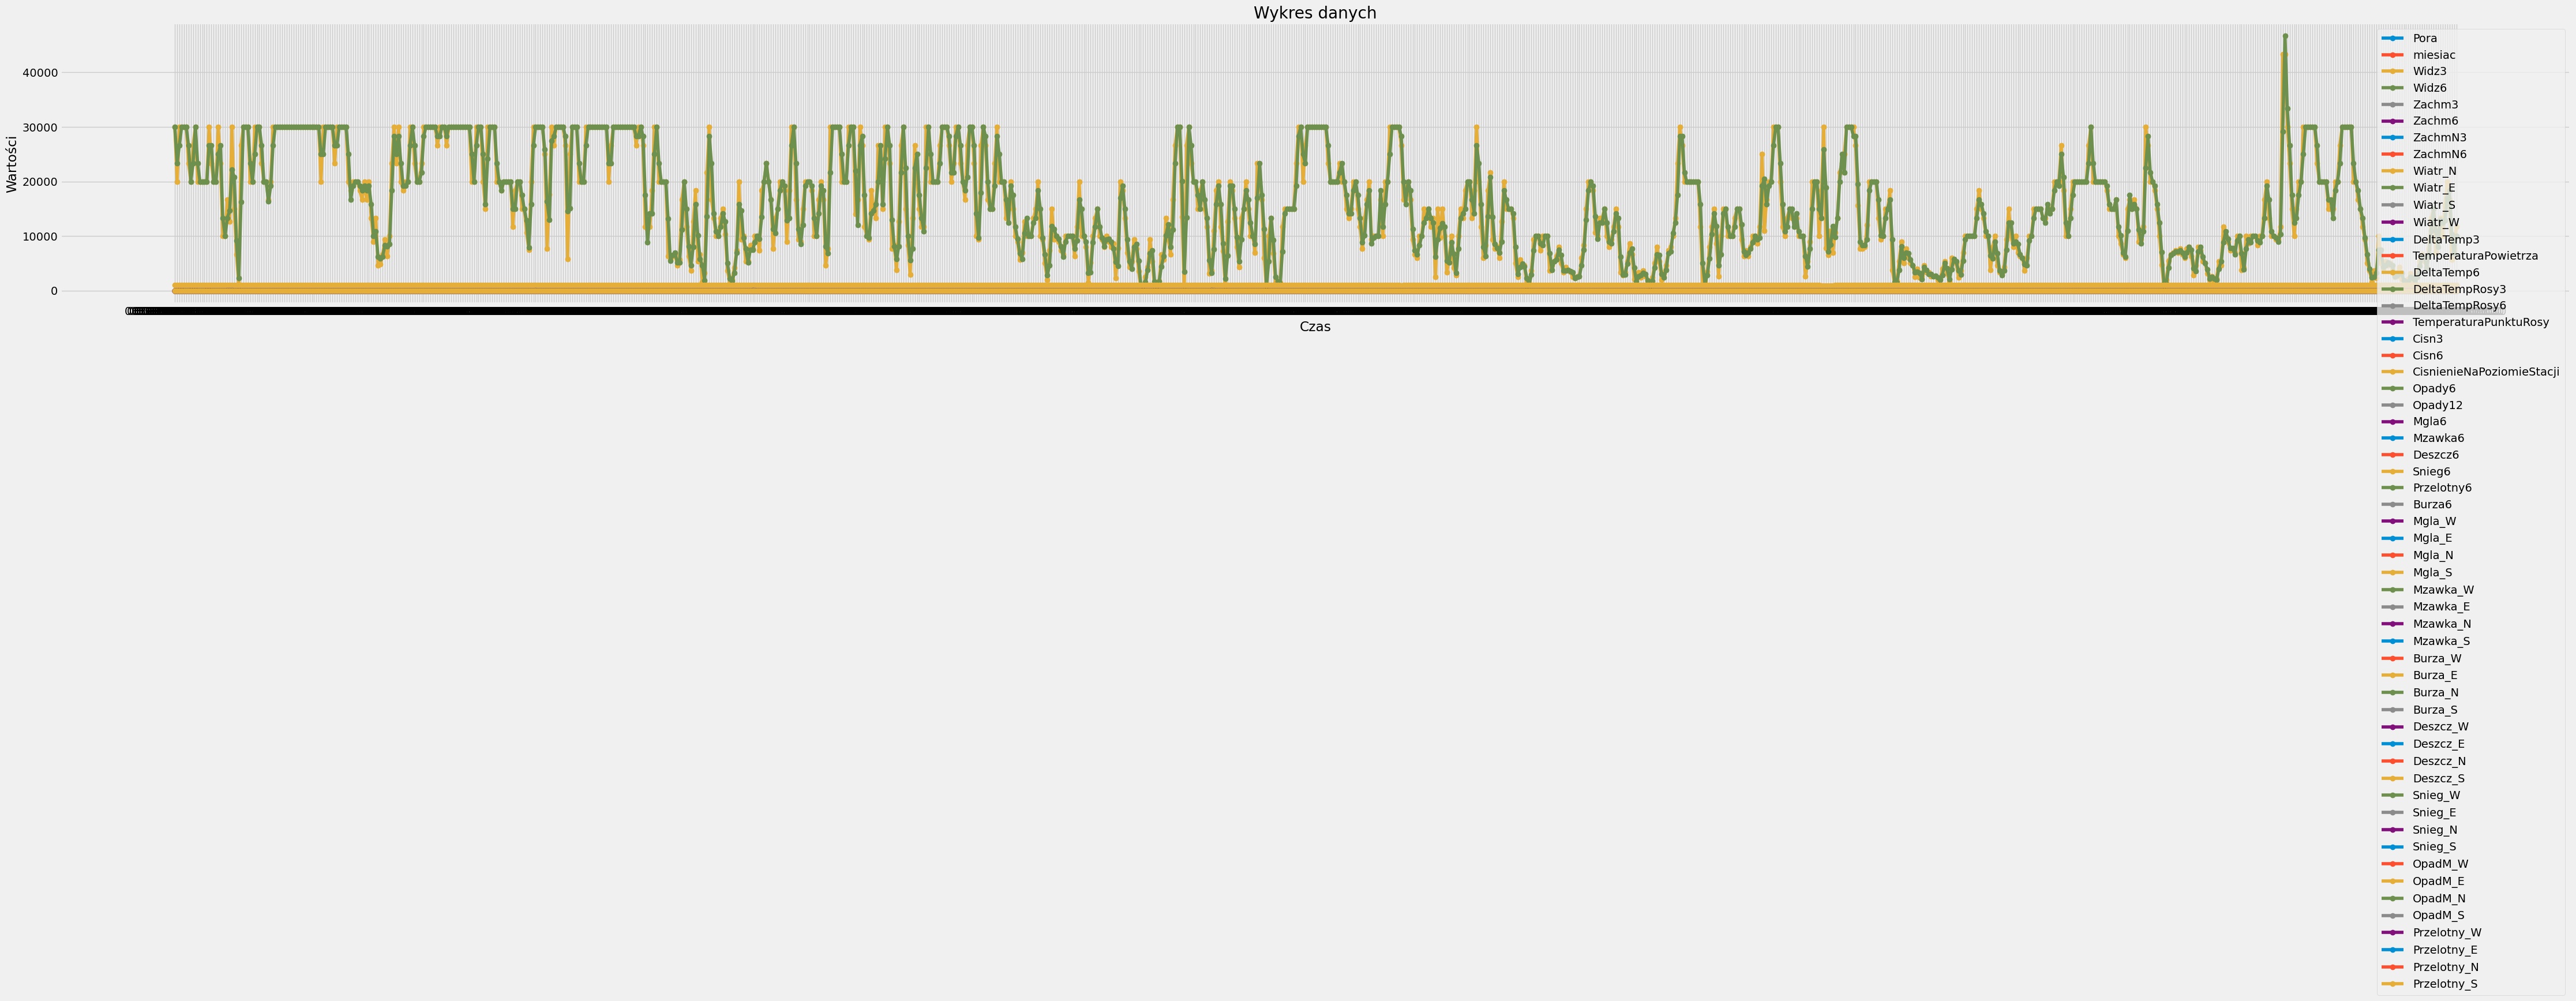

In [105]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_from_dataframe(df):
    # Sprawdzenie, czy DataFrame ma odpowiednią liczbę kolumn
    if df.shape[1] < 62:
        raise ValueError("DataFrame musi zawierać co najmniej 62 kolumny.")
    
    # Ustawienie kolumny 'czas' jako indeksu DataFrame, jeśli jeszcze nie jest
    if df.columns[0] == 'czas' and not df.index.name == 'czas':
        df_plot = df.set_index('czas')
    
    # Wybór kolumn do wykresu, pomijając pierwszą (indeks) i jeszcze jedną kolumnę
    # Zakładamy, że chcemy pominąć 60. kolumnę i użyć 61. i 62.
    columns_to_plot = df.columns[1:58]
    
    # Tworzenie wykresu dla wybranych kolumn
    plt.figure(figsize=(50, 6))
    for column in columns_to_plot:
        plt.plot(df.index, df[column], marker='o', linestyle='-', label=column)
    
    plt.title('Wykres danych')
    plt.xlabel('Czas')
    plt.ylabel('Wartości')
    plt.legend()
    plt.grid(True)
    plt.show()

# Przykładowe użycie
# Zakładając, że `df` to Twój DataFrame
plot_from_dataframe(df_plot)


In [106]:
#Create a new dataframe with only the 'Close' column
data = df['Widz6']
#Convert the dataframe to a numpy array
dataset = data.values
#Get /Compute the number of rows to train the model on
training_data_len = math.ceil( len(dataset) *.8)
training_data_len

122216

In [107]:
dataset

array([30000, 23333, 26666, ...,  2750,  2383,  2216])

In [109]:
#Scale the all of the data to be values between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset.reshape(-1, 1))
scaled_data

array([[0.59893316],
       [0.46523753],
       [0.53207532],
       ...,
       [0.0524796 ],
       [0.04512002],
       [0.04177111]])

In [110]:
#Create the scaled training data set
train_data = scaled_data[0:training_data_len  , : ]
#Split the data into x_train and y_train data sets
x_train=[]
y_train = []
for i in range(60,len(train_data)):
    x_train.append(train_data[i-60:i,0])
    y_train.append(train_data[i,0])
    if i<= 61:
        print('x_train=\n', x_train)
        print('y_train=\n', y_train)
        print('---')

x_train=
 [array([0.59893316, 0.46523753, 0.53207532, 0.59893316, 0.59893316,
       0.59893316, 0.53207532, 0.39839974, 0.46523753, 0.59893316,
       0.46523753, 0.39839974, 0.39839974, 0.39839974, 0.39839974,
       0.53207532, 0.53207532, 0.39839974, 0.39839974, 0.49866645,
       0.53207532, 0.26470411, 0.19786632, 0.26470411, 0.29143522,
       0.44183528, 0.41510418, 0.18114184, 0.04277378, 0.3228588 ,
       0.59893316, 0.59893316, 0.59893316, 0.46523753, 0.39839974,
       0.49866645, 0.59893316, 0.59893316, 0.53207532, 0.39839974,
       0.39839974, 0.32486414, 0.38167526, 0.53207532, 0.59893316,
       0.59893316, 0.59893316, 0.59893316, 0.59893316, 0.59893316,
       0.59893316, 0.59893316, 0.59893316, 0.59893316, 0.59893316,
       0.59893316, 0.59893316, 0.59893316, 0.59893316, 0.59893316])]
y_train=
 [0.5989331622114826]
---
x_train=
 [array([0.59893316, 0.46523753, 0.53207532, 0.59893316, 0.59893316,
       0.59893316, 0.53207532, 0.39839974, 0.46523753, 0.59893316,
   

In [111]:
#Convert x_train and y_train to numpy arrays
X_train, x_train = np.array(x_train), np.array(y_train)

In [112]:
x_train

array([0.59893316, 0.59893316, 0.59893316, ..., 0.4485331 , 0.46523753,
       0.38167526])

In [141]:
x_train.shape

(122156,)

In [133]:
x_train.shape

(122156,)

In [134]:
x_train.shape

(122156,)

In [152]:
#Reshape the data into the shape accepted by the LSTM
x_train = np.reshape(x_train, (x_train.shape[0],len(x_train.shape),1))
x_train.shape

(122156, 1, 1)

In [167]:
#Build the LSTM network model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True,input_shape=(x_train.shape[1], 1)))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dense(units=25))
model.add(Dense(units=1))
def _is_distributed_dataset(ds):
#   return isinstance(ds, input_lib.DistributedDatasetInterface)
    return isinstance(ds, input_lib.DistributedDatasetSpec)

In [168]:
#Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])

In [179]:
X_train = np.array(x_train, dtype=np.float32)
y_train =  np.array(y_train, dtype=np.float32)
# X_test =  np.array(X_test, dtype=np.float32)
# y_test =  np.array(y_test, dtype=np.float32)

In [180]:
# Trenowanie modelu
model.fit(X_train, y_train, epochs=20, batch_size=1)

Epoch 1/20


2024-02-17 15:31:04.286876: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8902
2024-02-17 15:31:04.860190: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7f4c552a2200 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-02-17 15:31:04.860225: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2024-02-17 15:31:04.875526: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-02-17 15:31:04.996946: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


122156/122156 [==============================] - 819s 7ms/step - loss: 5.3509e-05 - accuracy: 2.4559e-05
Epoch 2/20
122156/122156 [==============================] - 801s 7ms/step - loss: 6.8002e-06 - accuracy: 2.4559e-05
Epoch 3/20
122156/122156 [==============================] - 802s 7ms/step - loss: 4.7158e-06 - accuracy: 2.4559e-05
Epoch 4/20
106345/122156 [=========================>....] - ETA: 3:36 - loss: 4.2319e-06 - accuracy: 2.8210e-05

InternalError: Could not synchronize CUDA stream: CUDA_ERROR_LAUNCH_TIMEOUT: the launch timed out and was terminated

In [170]:
model.summary()

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_6 (LSTM)               (None, 1, 50)             10400     
                                                                 
 lstm_7 (LSTM)               (None, 50)                20200     
                                                                 
 dense_6 (Dense)             (None, 25)                1275      
                                                                 
 dense_7 (Dense)             (None, 1)                 26        
                                                                 
Total params: 31901 (124.61 KB)
Trainable params: 31901 (124.61 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [162]:
#Test data set
#Create a new array containing scaled values from index 1543 to 2003
test_data = scaled_data[training_data_len: , : ]
#Create the x_test and y_test data sets
x_test = []
y_test =  dataset[training_data_len : , : ]
for i in range(60,len(test_data)):
    x_test.append(test_data[i-60:i,0])

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [158]:
#Convert x_test to a numpy array
x_test = np.array(x_test)

In [ ]:
#Reshape the data into the shape accepted by the LSTM
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

In [ ]:
#Getting the models predicted price values
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)#Undo scaling

In [ ]:
#Calculate/Get the value of RMSE
rmse=np.sqrt(np.mean(((predictions - y_test)**2)))
rmse

In [ ]:
threshold = 0.05  # Próg błędu (na przykład 5%)

# Oblicz procentową miarę poprawności
accuracy_percentage = (1 - (rmse / threshold)) * 100

print(f"Procentowa miara poprawności: {accuracy_percentage:.2f}%")

In [ ]:
#Plot/Create the data for the graph
train = data[:training_data_len]
train['Date'] = df['Date'][ :training_data_len]
# train.set.index = 'Date'
train = train.reset_index()
train.set_index('Date', inplace=True)
print('train=', train)

valid = data[training_data_len:]
valid['Date'] = df['Date'][training_data_len:]
valid['Predictions'] = predictions
valid = valid.reset_index()
valid.set_index('Date', inplace=True)
print('valid=', valid)
# print('train=', train)
#Visualize the data
plt.figure(figsize=(16,8))

# plt.plot(df['Date'][:7928], train['Close'], color='g', lw=1)
# plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
# plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.YearLocator(2))  # Co 2 lata
plt.title('Model')

# plt.plot(df['Date'], df['Value'], marker='o', linestyle='-', color='b', lw=2)
# plt.xlabel('Date', fontsize=18)
plt.xticks(df['Date'], rotation=45)
plt.xlabel('Data', fontsize=18)
plt.ylabel('Close Price EURUSD D1', fontsize=18)
# plt.plot(train['Close'], lw=1)
# plt.plot(valid[['Close']], color='g', lw=1)
# plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
# plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.YearLocator(1))  # Co 2 lata

## wyświetlanie tylko predykcji
plt.plot(valid[['Close']], color='g', lw=1)
# plt.plot(train[['Close']], color='m', lw=1)
plt.plot(valid[['Predictions']], color='r', lw=1)
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.YearLocator(1))  # Co ile lat
plt.legend(['Close Price EURUSD D1 ', 'Predictions'], loc='upper right')
plt.show()


# #wyświetlanie treningu, notowań i predykcji
# plt.plot(valid[['Close']], color='g', lw=1)
# plt.plot(train[['Close']], color='m', lw=1)
# plt.plot(valid[['Predictions']], color='r', lw=1)
# plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
# plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.YearLocator(2))  # Co ile lat
# plt.legend(['Close Price USD','Train', 'Predictions'], loc='upper right')
# plt.show()

In [ ]:
valid_tail = valid.tail(50)
valid_tail['Predictions'] = valid_tail['Predictions'].shift(-1)
valid_tail['Tommorow'] = valid_tail['Close'].shift(-0)

In [ ]:
plt.figure(figsize=(16,8))
plt.plot(valid_tail[['Tommorow']], color='g', lw=1)
plt.plot(valid_tail[['Predictions']], color='r', lw=1)
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.YearLocator(1))  # Co ile lat
plt.legend(['Close EURUSD D1 ', 'Tommorow Predictions'], loc='upper right')
# plt.legend(['Close Price EURUSD D1 ', 'Predictions'], loc='upper right')
plt.show()


In [ ]:
valid